In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


NumPy: 2.4.6
Pandas: 2.3.3


In [13]:
df = pd.read_csv("D:/Veda Internship/Sakshi/Super_Store_DataCleaning/OTT_Streaming_Content_Trend_Analysis_Day31/Dataset/netflix_titles.csv")

In [14]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [15]:
df.shape

(6234, 12)

In [16]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 6234
Columns: 12


In [17]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       6234 non-null   int64 
 1   type          6234 non-null   object
 2   title         6234 non-null   object
 3   director      4265 non-null   object
 4   cast          5664 non-null   object
 5   country       5758 non-null   object
 6   date_added    6223 non-null   object
 7   release_year  6234 non-null   int64 
 8   rating        6224 non-null   object
 9   duration      6234 non-null   object
 10  listed_in     6234 non-null   object
 11  description   6234 non-null   object
dtypes: int64(2), object(10)
memory usage: 584.6+ KB


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
missing = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing.sort_values(
    by='Missing_Count',
    ascending=False
)

,Missing_Count,Missing_Percentage
director,1969,31.584857
cast,570,9.143407
country,476,7.635547
date_added,11,0.176452
rating,10,0.160411
title,0,0.000000
show_id,0,0.000000
type,0,0.000000
release_year,0,0.000000
duration,0,0.000000


In [22]:
df['director'] = df['director'].fillna('Unknown')

df['cast'] = df['cast'].fillna('Unknown')

df['country'] = df['country'].fillna('Unknown')

df['rating'] = df['rating'].fillna('Unknown')

In [23]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

In [24]:
df['date_added'].dtype

dtype('<M8[ns]')

In [25]:
df['added_year'] = df['date_added'].dt.year

In [26]:
df['added_month'] = df['date_added'].dt.month

In [27]:
type_counts = df['type'].value_counts()

print(type_counts)

type
Movie      4265
TV Show    1969
Name: count, dtype: int64


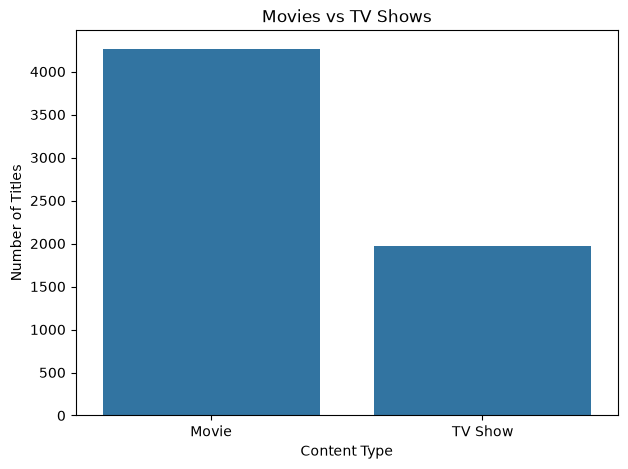

In [38]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='type'
)

plt.title('Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.savefig(
    r'D:\Veda Internship\Sakshi\Super_Store_DataCleaning\OTT_Streaming_Content_Trend_Analysis_Day31\Charts\01_movies_vs_tv_shows.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [39]:
type_percentage = (
    df['type']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(type_percentage)

type
Movie      68.42
TV Show    31.58
Name: proportion, dtype: float64


In [40]:
df['release_year'].describe()

count    6234.00000
mean     2013.35932
std         8.81162
min      1925.00000
25%      2013.00000
50%      2016.00000
75%      2018.00000
max      2020.00000
Name: release_year, dtype: float64

In [41]:
release_year = (
    df.groupby('release_year')
      .size()
      .reset_index(name='content_count')
)

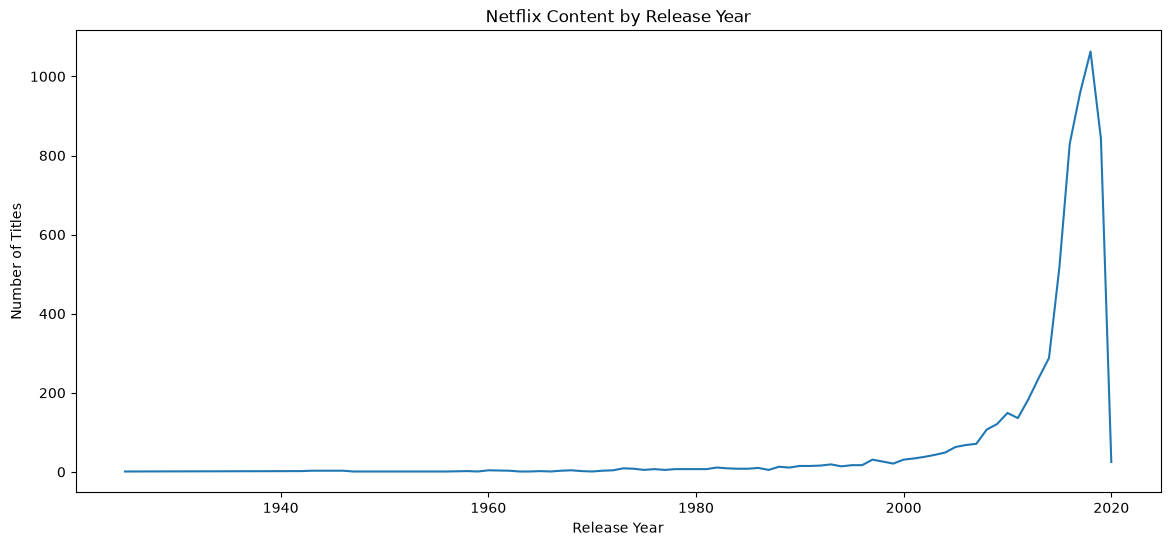

In [42]:
plt.figure(figsize=(14,6))

plt.plot(
    release_year['release_year'],
    release_year['content_count']
)

plt.title('Netflix Content by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.savefig(
    r'D:\Veda Internship\Sakshi\Super_Store_DataCleaning\OTT_Streaming_Content_Trend_Analysis_Day31\Charts\02_content_by_release_year.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [43]:
added_year = (
    df.groupby('added_year')
      .size()
      .reset_index(name='content_added')
)

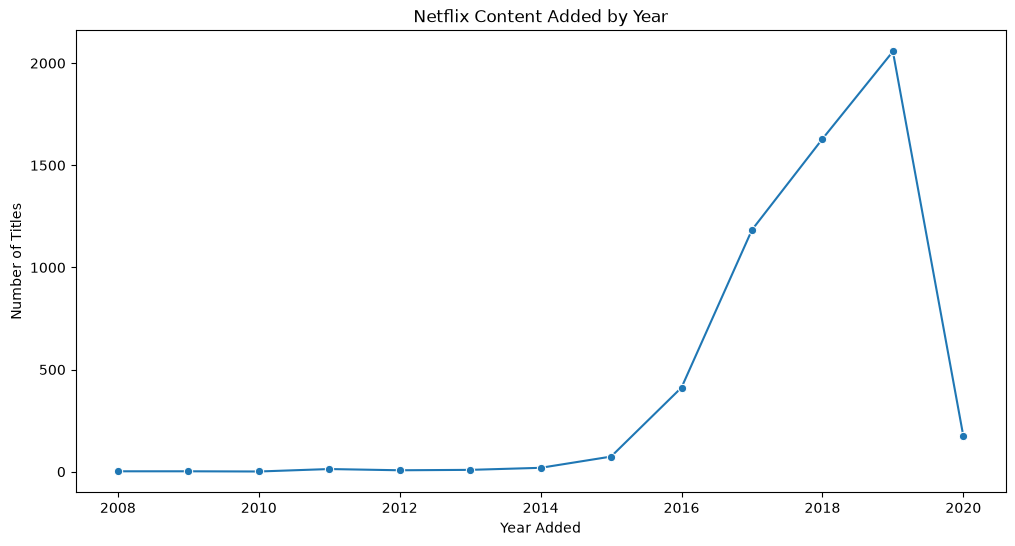

In [44]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=added_year,
    x='added_year',
    y='content_added',
    marker='o'
)

plt.title('Netflix Content Added by Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.savefig(
    r'D:\Veda Internship\Sakshi\Super_Store_DataCleaning\OTT_Streaming_Content_Trend_Analysis_Day31\Charts\03_content_added_by_year.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [45]:
genre_df = df.assign(
    genre=df['listed_in'].str.split(', ')
).explode('genre')

In [46]:
genre_df[['title', 'genre']].head()

,title,genre
0,Norm of the North: King Sized Adventure,Children & Family Movies
0,Norm of the North: King Sized Adventure,Comedies
1,Jandino: Whatever it Takes,Stand-Up Comedy
2,Transformers Prime,Kids' TV
3,Transformers: Robots in Disguise,Kids' TV


In [47]:
genre_counts = (
    genre_df['genre']
    .value_counts()
)

print(genre_counts.head(15))

genre
International Movies        1927
Dramas                      1623
Comedies                    1113
International TV Shows      1001
Documentaries                668
TV Dramas                    599
Action & Adventure           597
Independent Movies           552
TV Comedies                  436
Thrillers                    392
Children & Family Movies     378
Romantic Movies              376
Crime TV Shows               363
Kids' TV                     328
Stand-Up Comedy              281
Name: count, dtype: int64


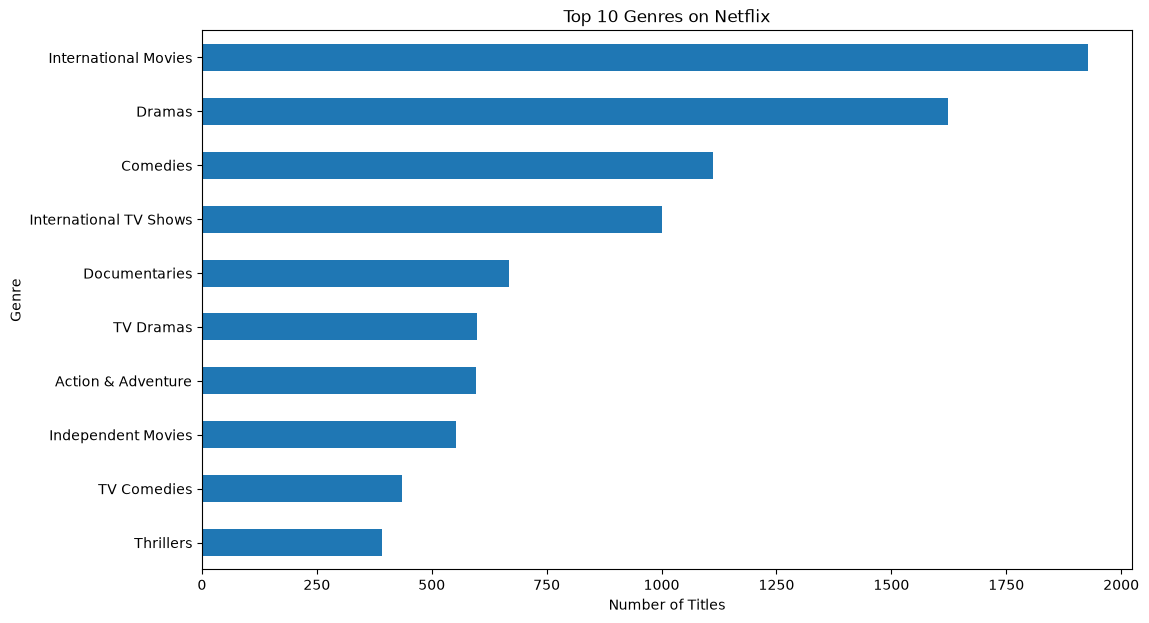

In [48]:
plt.figure(figsize=(12,7))

genre_counts.head(10).sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.savefig(
    r'D:\Veda Internship\Sakshi\Super_Store_DataCleaning\OTT_Streaming_Content_Trend_Analysis_Day31\Charts\04_top_10_genres.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [49]:
genre_year = (
    genre_df
    .groupby(['release_year', 'genre'])
    .size()
    .reset_index(name='content_count')
)

In [50]:
top_5_genres = genre_counts.head(5).index

In [51]:
genre_trend = genre_year[
    genre_year['genre'].isin(top_5_genres)
]

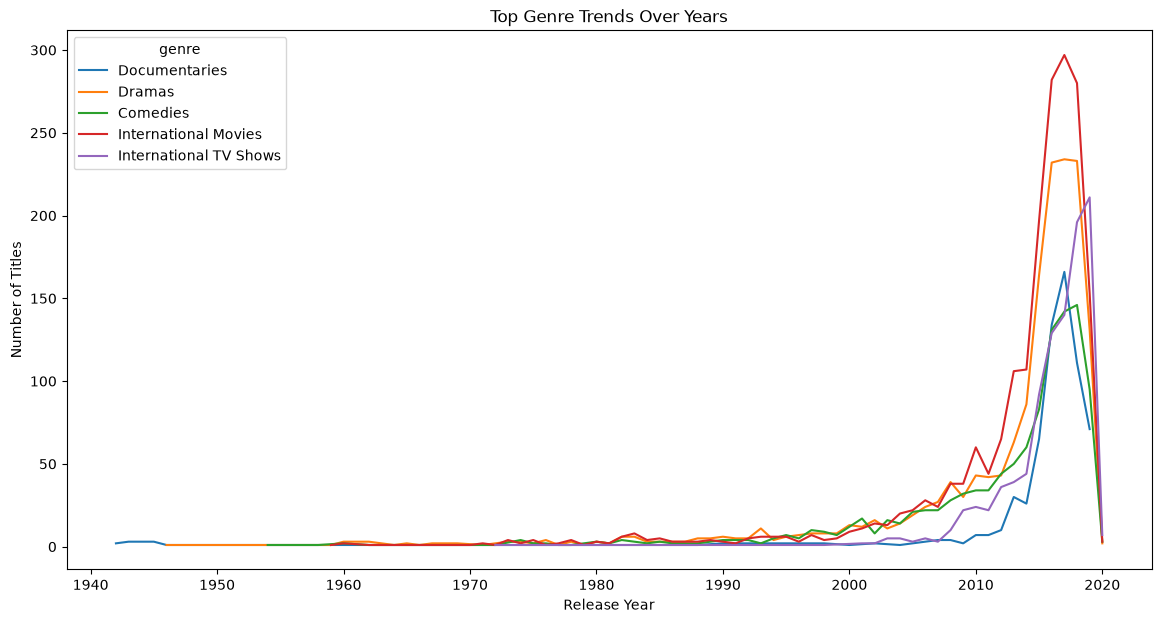

In [52]:
plt.figure(figsize=(14,7))

sns.lineplot(
    data=genre_trend,
    x='release_year',
    y='content_count',
    hue='genre'
)

plt.title('Top Genre Trends Over Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.savefig(
    r'D:\Veda Internship\Sakshi\Super_Store_DataCleaning\OTT_Streaming_Content_Trend_Analysis_Day31\Charts\05_genre_trends.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [53]:
country_df = df.assign(
    country_name=df['country'].str.split(', ')
).explode('country_name')

In [54]:
country_counts = country_df['country_name'].value_counts()

print(country_counts.head(15))

country_name
United States     2609
India              838
United Kingdom     601
Unknown            476
Canada             318
France             271
Japan              231
Spain              178
South Korea        162
Germany            151
Mexico             129
Australia          126
China              120
Hong Kong           97
Turkey              87
Name: count, dtype: int64


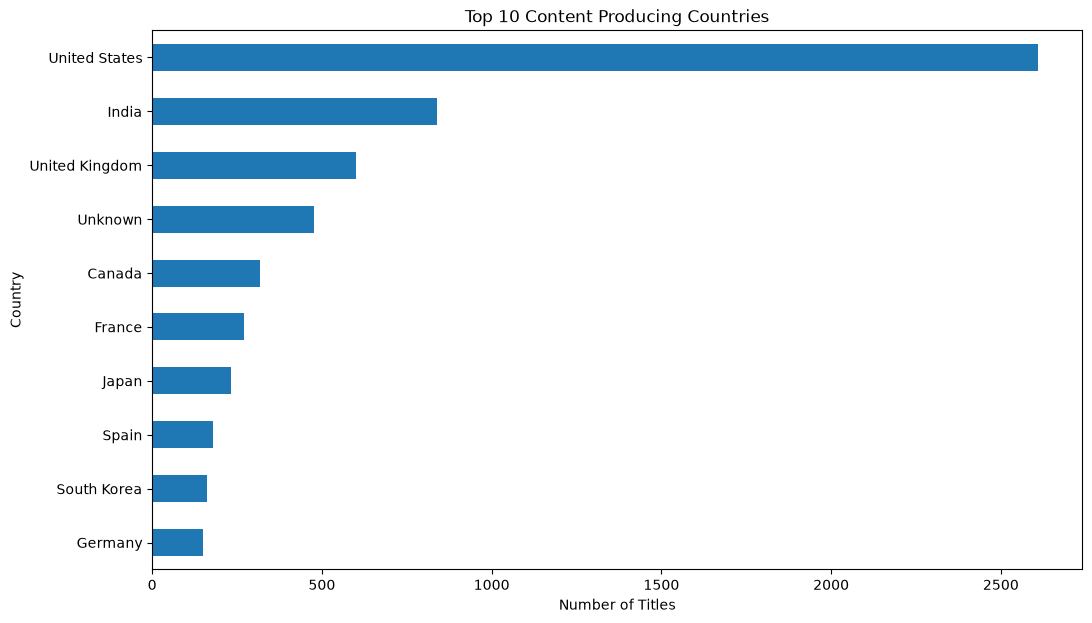

In [55]:
plt.figure(figsize=(12,7))

country_counts.head(10).sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Content Producing Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.savefig(
    r'D:\Veda Internship\Sakshi\Super_Store_DataCleaning\OTT_Streaming_Content_Trend_Analysis_Day31\Charts\06_top_10_countries.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [56]:
india_content = country_df[
    country_df['country_name'] == 'India'
]

print("Indian Titles:", india_content['title'].nunique())

Indian Titles: 834


In [57]:
india_type = (
    india_content
    .groupby('type')['title']
    .nunique()
)

print(india_type)

type
Movie      779
TV Show     55
Name: title, dtype: int64


In [58]:
india_genres = genre_df[
    genre_df['title'].isin(india_content['title'])
]

print(
    india_genres['genre']
    .value_counts()
    .head(10)
)

genre
International Movies      722
Dramas                    543
Comedies                  248
Independent Movies        131
Action & Adventure        129
Music & Musicals           92
Romantic Movies            91
Thrillers                  74
International TV Shows     48
Horror Movies              32
Name: count, dtype: int64


In [59]:
rating_counts = df['rating'].value_counts()

print(rating_counts)

rating
TV-MA       2027
TV-14       1698
TV-PG        701
R            508
PG-13        286
NR           218
PG           184
TV-Y7        169
TV-G         149
TV-Y         143
TV-Y7-FV      95
G             37
Unknown       10
UR             7
NC-17          2
Name: count, dtype: int64


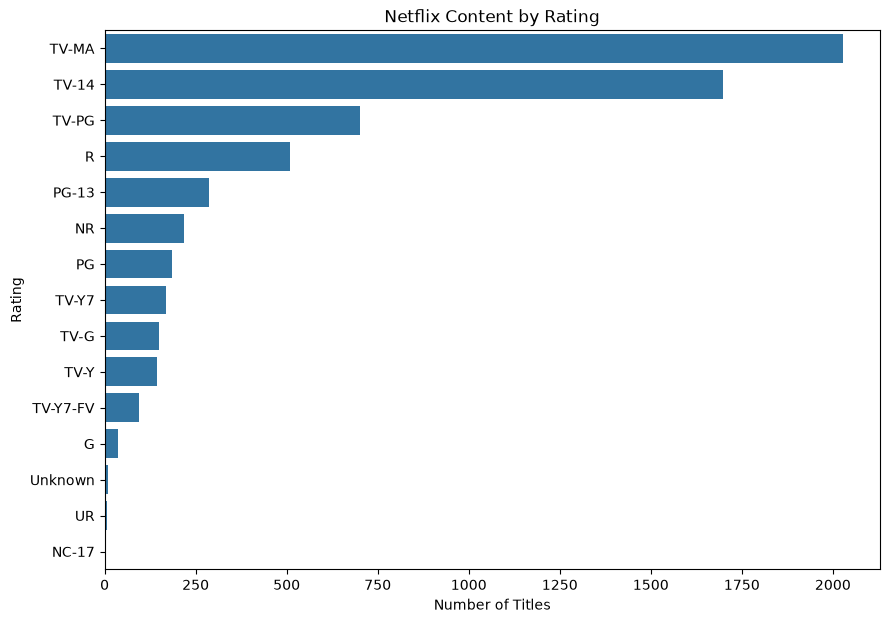

In [60]:
plt.figure(figsize=(10,7))

sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index
)

plt.title('Netflix Content by Rating')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')
plt.savefig(
    r'D:\Veda Internship\Sakshi\Super_Store_DataCleaning\OTT_Streaming_Content_Trend_Analysis_Day31\Charts\07_content_by_rating.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [61]:
df['duration_value'] = (
    df['duration']
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

In [62]:
movies = df[df['type'] == 'Movie'].copy()

In [63]:
movies['duration_value'].describe()

count    4265.000000
mean       99.100821
std        28.074857
min         3.000000
25%        86.000000
50%        98.000000
75%       115.000000
max       312.000000
Name: duration_value, dtype: float64

In [64]:
print(
    "Average Movie Duration:",
    movies['duration_value'].mean()
)

Average Movie Duration: 99.10082063305978


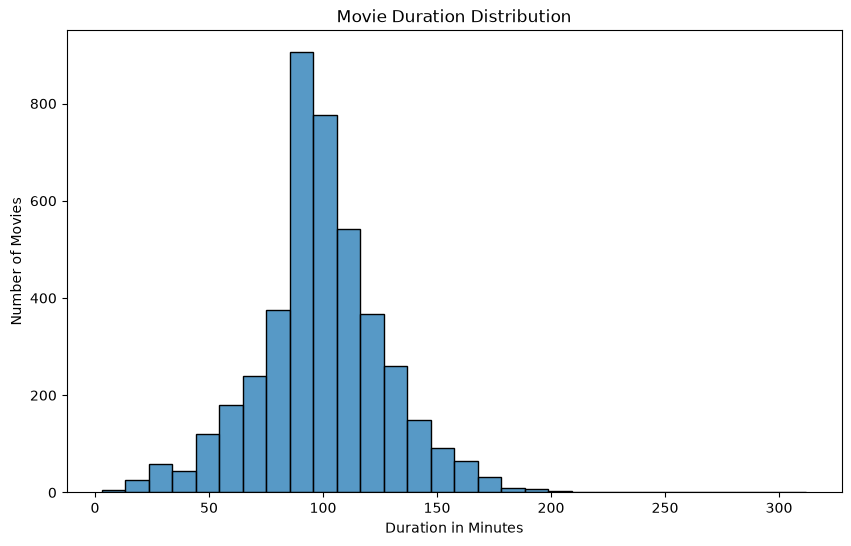

In [65]:
plt.figure(figsize=(10,6))

sns.histplot(
    movies['duration_value'].dropna(),
    bins=30
)

plt.title('Movie Duration Distribution')
plt.xlabel('Duration in Minutes')
plt.ylabel('Number of Movies')
plt.savefig(
    r'D:\Veda Internship\Sakshi\Super_Store_DataCleaning\OTT_Streaming_Content_Trend_Analysis_Day31\Charts\08_movie_duration_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [66]:
tv_shows = df[df['type'] == 'TV Show'].copy()

In [67]:
tv_shows['duration_value'].describe()

count    1969.000000
mean        1.779584
std         1.624936
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        15.000000
Name: duration_value, dtype: float64

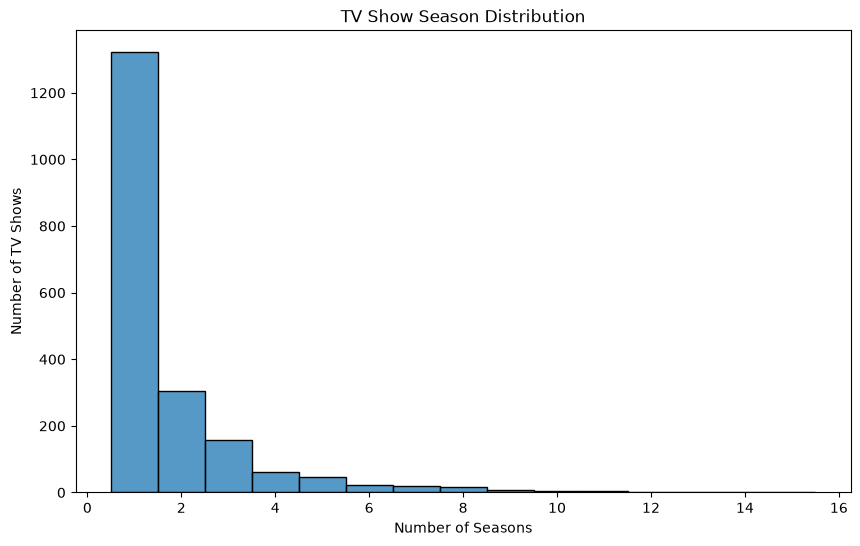

In [68]:
plt.figure(figsize=(10,6))

sns.histplot(
    tv_shows['duration_value'].dropna(),
    discrete=True
)

plt.title('TV Show Season Distribution')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.savefig(
    r'D:\Veda Internship\Sakshi\Super_Store_DataCleaning\OTT_Streaming_Content_Trend_Analysis_Day31\Charts\09_tv_show_seasons.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [69]:
total_titles = df['title'].nunique()

total_movies = df[
    df['type'] == 'Movie'
]['title'].nunique()

total_tv_shows = df[
    df['type'] == 'TV Show'
]['title'].nunique()

total_genres = genre_df['genre'].nunique()

total_countries = country_df[
    country_df['country_name'] != 'Unknown'
]['country_name'].nunique()

print("========== OTT CONTENT KPIs ==========")
print("Total Titles:", total_titles)
print("Movies:", total_movies)
print("TV Shows:", total_tv_shows)
print("Genres:", total_genres)
print("Countries:", total_countries)

========== OTT CONTENT KPIs ==========
Total Titles: 6172
Movies: 4241
TV Shows: 1958
Genres: 42
Countries: 113


Business Insights

Insight 1 — Content Mix

Observation:

The Netflix catalog contains substantially more movies than TV shows, indicating that movies form the larger portion of the available catalog.

Business implication:

The platform can use TV series strategically for longer-term viewer engagement while maintaining its strong movie library.

Insight 2 — Genre

After you actually run your genre analysis, write:

The analysis identifies the most represented genres in the Netflix catalog. The trend analysis shows whether these genres have remained consistently important or changed over time.

Don't claim a genre is "most popular" unless your dataset actually measures popularity. Your dataset measures catalog representation, not views or ratings.

This is an important point to mention in your report.

Insight 3 — Regional Content

After your country analysis:

The country analysis shows that content production is concentrated in a number of major markets, while regional markets provide opportunities for further content expansion.

3 Content Strategy Recommendations

Based on your actual output, write recommendations like:

Recommendation 1 — Strengthen High-Growth Genres

Identify genres showing consistent growth in the recent release years and prioritize them for future content acquisition and production.

Recommendation 2 — Expand Regional Content

Increase investment in regional markets where the existing catalog demonstrates strong content contribution but there may be opportunities for additional local-language programming.

Recommendation 3 — Balance Movies and TV Shows

Maintain a strong movie portfolio while selectively increasing TV series in genres where multi-season storytelling can support longer-term audience engagement.

In [5]:
import pandas as pd

file_path = r"D:\Veda Internship\Sakshi\Super_Store_DataCleaning\OTT_Streaming_Content_Trend_Analysis_Day31\Dataset\netflix_titles.csv"

df = pd.read_csv(file_path)

print(df.shape)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance
    app.start()
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\kernelapp.py", line 807,

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance
    app.start()
  File "C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\kernelapp.py", line 807,

AttributeError: _ARRAY_API not found

(6234, 12)


In [6]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="ott_streaming_analysis"
)

cursor = conn.cursor()

print("MySQL connection successful!")

MySQL connection successful!


In [7]:
cursor.execute("DROP TABLE IF EXISTS netflix_titles")

cursor.execute("""
CREATE TABLE netflix_titles (
    show_id VARCHAR(20),
    type VARCHAR(20),
    title VARCHAR(500),
    director TEXT,
    cast TEXT,
    country TEXT,
    date_added VARCHAR(50),
    release_year INT,
    rating VARCHAR(20),
    duration VARCHAR(50),
    listed_in TEXT,
    description TEXT
)
""")

print("Table created successfully!")

Table created successfully!


In [8]:
df = df.where(pd.notna(df), None)

insert_query = """
INSERT INTO netflix_titles
(
    show_id,
    type,
    title,
    director,
    cast,
    country,
    date_added,
    release_year,
    rating,
    duration,
    listed_in,
    description
)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

batch_size = 500

for start in range(0, len(df), batch_size):

    batch = df.iloc[start:start + batch_size]

    rows = [
        tuple(row)
        for row in batch.itertuples(index=False, name=None)
    ]

    cursor.executemany(insert_query, rows)

    conn.commit()

    print(
        f"Inserted {min(start + batch_size, len(df))} / {len(df)} rows"
    )

print("All data inserted successfully!")

Inserted 500 / 6234 rows
Inserted 1000 / 6234 rows
Inserted 1500 / 6234 rows
Inserted 2000 / 6234 rows
Inserted 2500 / 6234 rows
Inserted 3000 / 6234 rows
Inserted 3500 / 6234 rows
Inserted 4000 / 6234 rows
Inserted 4500 / 6234 rows
Inserted 5000 / 6234 rows
Inserted 5500 / 6234 rows
Inserted 6000 / 6234 rows
Inserted 6234 / 6234 rows
All data inserted successfully!


In [9]:
cursor.execute("SELECT COUNT(*) FROM netflix_titles")

result = cursor.fetchone()

print("Total rows in MySQL:", result[0])

Total rows in MySQL: 6234


In [10]:
cursor.close()
conn.close()

print("Connection closed.")

Connection closed.
